In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import scipy.stats
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
from tensorflow.keras.initializers import he_normal
import datetime
from os import listdir
import os
import random

In [ ]:
# colNum = 40  # Column number of genoMap
# rowNum = 40  # Row number of genoMap

In [ ]:
# high_data = pd.read_csv('/content/drive/MyDrive/Ahsan 11.7.2024/10. HIgh_Top_1600_Genes_Name.csv', header=None)
# high_dataNorm = scipy.stats.zscore(high_data, axis=0, ddof=1)
# high_genoMaps = gp.construct_genomap(high_dataNorm, rowNum, colNum, epsilon=0.0, num_iter=200)

In [ ]:
# low_data = pd.read_csv('/content/drive/MyDrive/Ahsan 11.7.2024/4. Low_Top_1600_Genes_Name - Copy.csv', header=None)
# low_dataNorm = scipy.stats.zscore(low_data, axis=0, ddof=1)
# low_genoMaps = gp.construct_genomap(low_dataNorm, rowNum, colNum, epsilon=0.0, num_iter=200)

In [ ]:
# np.save('/content/drive/MyDrive/Ahsan 11.7.2024/high_genomap.npy', high_genoMaps)

In [ ]:
# np.save('/content/drive/MyDrive/Ahsan 11.7.2024/low_genomap.npy', low_genoMaps)

In [ ]:
batch_size = 64
num_channels = 1
image_size = 40
latent_dim = 128
num_features = 1

b = low mono = high

In [ ]:
low_data = np.load('/content/drive/MyDrive/Ahsan/11. Cancer Data on 30th April/Real_Low_genomap.npy')
high_data = np.load('/content/drive/MyDrive/Ahsan/11. Cancer Data on 30th April/Real_High_genomap.npy')

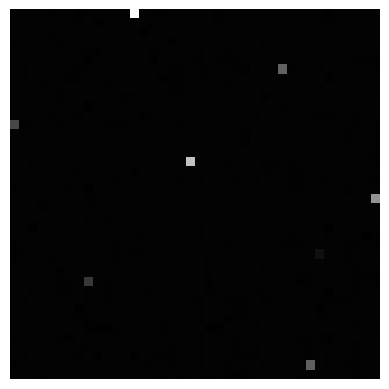

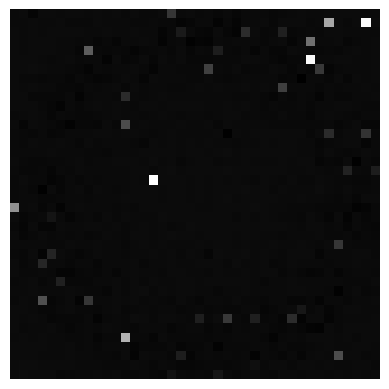

In [ ]:
image = low_data[777]
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

image = high_data[1000]
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
# Print the shape of the file
print("Shape of low_Class_genomap.npy:", low_data.shape)

Shape of low_Class_genomap.npy: (1415, 40, 40, 1)


In [ ]:
print(low_data.min(),low_data.max())
print(high_data.min(),high_data.max())

-0.48987192 37.5899
-0.73866487 37.5899


In [ ]:
Y = [-0.5] * low_data.shape[0] +  [0.5] * high_data.shape[0]
Y = np.asarray(Y, 'float32').reshape((-1,1))

In [ ]:
data = np.vstack([low_data, high_data ])
data = data.astype(np.float32)
#data = np.clip(data , -5 ,5)
_MIN = data.min()
_MAX = data.max()
data = -1 + 2*(data - _MIN)/(_MAX - _MIN)

In [ ]:
print(data.min(),data.max())

-1.0 1.0


In [ ]:
# Print the first 5 rows and first 5 columns of the array (adjust slicing as needed)
print("Snippet of normalized data:")
print(data[:5, :5])  # This will show the first 5 rows and 5 columns

Snippet of normalized data:
[[[[-0.96468467]
   [-0.96284336]
   [-0.96284336]
   [-0.9634186 ]
   [-0.9671509 ]
   [-0.9638605 ]
   [-0.9638605 ]
   [-0.97009623]
   [-0.96496344]
   [-0.96284336]
   [-0.96372277]
   [-0.96382374]
   [-0.96284336]
   [-0.9683694 ]
   [-0.96284336]
   [-0.9649722 ]
   [-0.96642745]
   [-0.9645999 ]
   [-0.96423346]
   [-0.96377593]
   [-0.96456236]
   [-0.96382374]
   [-0.97102636]
   [-0.9638605 ]
   [-0.96284336]
   [-0.96423346]
   [-0.9634186 ]
   [-0.96284336]
   [-0.96408004]
   [-0.96423346]
   [-0.96331775]
   [-0.9634186 ]
   [-0.96284336]
   [-0.9638605 ]
   [-0.96986634]
   [-0.9634186 ]
   [-0.9640906 ]
   [-0.9638605 ]
   [-0.9634186 ]
   [-0.96331775]]

  [[-0.96440244]
   [-0.96423346]
   [-0.96408004]
   [-0.96284336]
   [-0.96313864]
   [-0.9641519 ]
   [-0.9655192 ]
   [-0.9663843 ]
   [-0.9634186 ]
   [-0.96897477]
   [-0.965471  ]
   [-0.96396536]
   [-0.96372277]
   [-0.9634186 ]
   [-0.964698  ]
   [-0.96486   ]
   [-0.9632112 ]
 

In [ ]:
print(data.mean(),data.std())

-0.96145695 0.052137177


In [ ]:
# def map_fn(file_path, label):
#     img = tf.io.read_file(file_path)
#     img = tf.image.decode_png(img, channels=1)
#     img = tf.image.convert_image_dtype(img, tf.float32)
#     img =  2.0 * img - 1.0
#     label = label - 0.5
#     return img , label

In [ ]:
dataset = tf.data.Dataset.from_tensor_slices((data , Y ))
dataset = dataset.shuffle(buffer_size=1000)
dataset = dataset.batch(batch_size)

(64, 40, 40, 1)
(64, 1)
-0.98701787 1.0 -0.96150583 0.05101206
-0.5 -0.5 -0.5 0.0


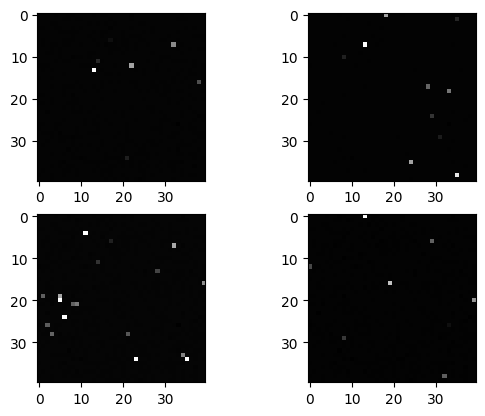

In [ ]:
for x, y in dataset.take(1):
  print(x.shape)
  print(y.shape)
  print(np.min(x),np.max(x),np.mean(x),np.std(x))
  print(np.min(y),np.max(y),np.mean(y),np.std(y))
  # x = np.clip(x, -1 ,1)
  x = x * 0.5 + 0.5
  #x = (x - np.min(x))/(np.max(x) - np.min(x))
  x *= 255.0
  #x = x.astype(np.uint8)
  for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(x[i] , cmap='gray')
  plt.show()

In [ ]:
generator_in_channels = latent_dim + num_features
discriminator_in_channels = num_channels + num_features
print(generator_in_channels, discriminator_in_channels)

129 2


In [ ]:
def get_discriminator():
  input_layer = layers.Input(shape=(image_size,image_size,num_channels+1))
  x = layers.Conv2D(32 , (3,3) , padding='same',strides=2,use_bias=True)(input_layer)
  x = layers.LeakyReLU(alpha=0.2)(x)
  x = layers.Conv2D(64 , (3,3) , padding='same',strides=2,use_bias=True)(x)
  x = layers.LeakyReLU(alpha=0.2)(x)
  x = layers.Conv2D(128 , (3,3) , padding='same',strides=2,use_bias=True)(x)
  x = layers.LeakyReLU(alpha=0.2)(x)
  # x = layers.Conv2D(256 , (3,3) , padding='same',strides=2,use_bias=True)(x)
  # x = layers.LeakyReLU(alpha=0.2)(x)
  x = layers.Flatten()(x)
  x = layers.Dropout(0.2)(x)
  x = layers.Dense(256 , activation='relu')(x)
  x = layers.Dropout(0.2)(x)
  x = layers.Dense(1)(x)
  model = tf.keras.models.Model(input_layer,x, name='discriminator')
  print(model.summary())
  return model

In [ ]:
def get_geneator():
  input_layer_z = layers.Input(shape=(latent_dim,))
  input_layer_c = layers.Input(shape=(num_features,))
  c_emmbeding = layers.Dense(128 , activation='tanh')(input_layer_c)
  x = layers.Concatenate(axis=1)([input_layer_z,c_emmbeding])
  x = layers.Dense(5 * 5 * (latent_dim+num_features))(x)
  # x = layers.BatchNormalization()(x)
  x = layers.LeakyReLU(alpha=0.2)(x)
  x = layers.Reshape((5, 5, latent_dim+num_features))(x)
  x = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding="same",use_bias=True)(x)
  # x = layers.BatchNormalization()(x)
  x = layers.LeakyReLU(alpha=0.2)(x)
  x = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same",use_bias=True)(x)
  # x = layers.BatchNormalization()(x)
  x = layers.LeakyReLU(alpha=0.2)(x)
  x = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same",use_bias=True)(x)
  # x = layers.BatchNormalization()(x)
  x = layers.LeakyReLU(alpha=0.2)(x)
  x = layers.Conv2DTranspose(16, (2, 2), strides=(1, 1), padding="same",use_bias=True)(x)
  # x = layers.BatchNormalization()(x)
  x = layers.LeakyReLU(alpha=0.2)(x)
  x = layers.Conv2DTranspose(num_channels, (2, 2), strides=(1, 1), padding="same",use_bias=True)(x)
  #x = layers.BatchNormalization()(x)
  x = layers.Activation("tanh")(x)
  model = tf.keras.models.Model([input_layer_z,input_layer_c],x, name='generator')
  print(model.summary())
  return model


In [ ]:

class ConditionalGAN(tf.keras.Model):
    def __init__(self, discriminator, generator, latent_dim,batch_size):
        super(ConditionalGAN, self).__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        self.gen_loss_tracker = tf.keras.metrics.Mean(name="generator_loss")
        self.disc_loss_tracker = tf.keras.metrics.Mean(name="discriminator_loss")
        self.batch_size = batch_size
        self.d_steps = 3
        self.gp_weight = 10
        self.d_losses = []
        self.g_losses = []

    @property
    def metrics(self):
        return [self.gen_loss_tracker, self.disc_loss_tracker]
        # return [self.gen_loss_tracker, tf.keras.metrics.Accuracy()]

    def compile(self, d_optimizer, g_optimizer, d_loss_fn,g_loss_fn):
        super(ConditionalGAN, self).compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.d_loss_fn = d_loss_fn
        self.g_loss_fn = g_loss_fn

    def gradient_penalty(self, batch_size, real_images, fake_images):
        """ Calculates the gradient penalty.

        This loss is calculated on an interpolated image
        and added to the discriminator loss.
        """
        # Get the interpolated image
        alpha = tf.random.normal([batch_size, 1, 1, 1], 0.0, 1.0)
        diff = fake_images - real_images
        interpolated = real_images + alpha * diff

        with tf.GradientTape() as gp_tape:
            gp_tape.watch(interpolated)
            # 1. Get the discriminator output for this interpolated image.
            pred = self.discriminator(interpolated, training=True)

        # 2. Calculate the gradients w.r.t to this interpolated image.
        grads = gp_tape.gradient(pred, [interpolated])[0]
        # 3. Calculate the norm of the gradients.
        norm = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1, 2, 3]))
        gp = tf.reduce_mean((norm - 1.0) ** 2)
        return gp

    def train_step(self, data):
        # Unpack the data.
        real_images, features = data

        for i in range(self.d_steps):
            image_of_features = tf.repeat(
                      features, repeats=[image_size * image_size] ,axis=1
                  )
            image_of_features = tf.reshape(
                image_of_features, (-1, image_size, image_size, 1)
            )
            batch_size = tf.shape(real_images)[0]
            random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
            # random_vector_features = tf.concat(
            #     [random_latent_vectors, features], axis=1
            # )

            with tf.GradientTape() as tape:
                self.discriminator.trainable = True
                # Generate fake images from the latent vector
                fake_images = self.generator([random_latent_vectors, features],training=True)
                fake_image_and_features = tf.concat([fake_images, image_of_features], -1)
                real_image_and_features = tf.concat([real_images, image_of_features], -1)

                # Get the logits for the fake images
                fake_logits = self.discriminator(fake_image_and_features, training=True)

                # Get the logits for the real images
                real_logits = self.discriminator(real_image_and_features, training=True)

                # Calculate the discriminator loss using the fake and real image logits
                d_cost = self.d_loss_fn(real_img=real_logits, fake_img=fake_logits)
                # Calculate the gradient penalty
                gp = self.gradient_penalty(batch_size, real_image_and_features, fake_image_and_features)
                # Add the gradient penalty to the original discriminator loss
                d_loss = d_cost + gp * self.gp_weight

            # Get the gradients w.r.t the discriminator loss
            d_gradient = tape.gradient(d_loss, self.discriminator.trainable_variables)
            # Update the weights of the discriminator using the discriminator optimizer
            self.d_optimizer.apply_gradients(
                zip(d_gradient, self.discriminator.trainable_variables)
            )


        # Train the generator
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        # random_vector_features = tf.concat(
        #         [random_latent_vectors, features], axis=1
        #     )

        with tf.GradientTape(watch_accessed_variables=True) as g_tape:
            self.discriminator.trainable = False

            #g_tape.watch(self.generator.trainable_variables)

            # Generate fake images using the generator
            generated_images = self.generator([random_latent_vectors, features], training=True)
            # Get the discriminator logits for fake images
            fake_image_and_features = tf.concat([generated_images, image_of_features], -1)
            gen_img_logits = self.discriminator(fake_image_and_features, training=True)

            # Calculate the generator loss
            g_loss = self.g_loss_fn(gen_img_logits)

        # Get the gradients w.r.t the generator loss
        gen_gradient = g_tape.gradient(g_loss, self.generator.trainable_variables)
        # Update the weights of the generator using the generator optimizer
        self.g_optimizer.apply_gradients(
            zip(gen_gradient, self.generator.trainable_variables)
        )


        self.d_losses.append(d_loss)
        self.g_losses.append(g_loss)

        # Monitor loss.
        self.gen_loss_tracker.update_state(g_loss)
        self.disc_loss_tracker.update_state(d_loss)
        return {"d_loss": d_loss, "g_loss": g_loss}


In [ ]:
def discriminator_loss(real_img, fake_img):
    real_loss = tf.reduce_mean(real_img)
    fake_loss = tf.reduce_mean(fake_img)
    return fake_loss - real_loss


# Define the loss functions for the generator.
def generator_loss(fake_img):
    return -tf.reduce_mean(fake_img)

In [ ]:
classifier = tf.keras.models.load_model('/content/drive/MyDrive/Ahsan/11. Cancer Data on 30th April/classifier_del_later.h5')

In [ ]:

class GANMonitor(tf.keras.callbacks.Callback):
    def __init__(self, latent_dim=128, feature=[]):
        super(GANMonitor, self)
        self.latent_dim = latent_dim
        self.feature = feature


    def on_epoch_end(self, epoch, logs=None):
        # Sample noise for the interpolation.
        _noise = tf.random.normal(shape=(len(self.feature), latent_dim))
        labels = np.array(self.feature).reshape((len(self.feature),num_features))

        # Combine the noise and the labels and run inference with the generator.
        # _noise_and_labels = tf.concat([_noise, labels], 1)
        fake_images = self.model.generator.predict([_noise, labels])
        #print(f"mean {fake_images.mean()} std {fake_images.std()}")
        original_data = ((fake_images + 1) * (_MAX - _MIN) / 2) + _MIN
        y_ = classifier.predict(original_data)
        #print('prediction', y_)
        #fake_images = np.clip(fake_images, -1 ,1)
        # print(np.mean(fake_images))
        # print(np.std(fake_images))
        #fake_images = fake_images * 0.5 + 0.5
        fake_images = (fake_images - np.min(fake_images))/(np.max(fake_images) - np.min(fake_images))

        fake_images *= 255.0
        converted_images = fake_images.astype(np.uint8)




        if epoch % 300 == 0 :
            for i in range(4):
              plt.subplot(2,2,i+1)
              plt.imshow(converted_images[i], cmap='gray')
              # plt.imsave(root+'result/epoch {}_{}.png'.format(epoch,i),converted_images[i])
              # plt.imsave(root+'result/epoch {}_{}.png'.format(epoch,i),converted_images[i,:,:,0], cmap='gray')
            plt.show()

        if epoch % 5 == 0:
            print("saved on epoch", epoch)
            self.model.generator.save('/content/drive/MyDrive/Ahsan/11. Cancer Data on 30th April/Generator Model/generator_' + "Epoch-" + str(epoch) + ".h5")
            self.model.discriminator.save('/content/drive/MyDrive/Ahsan/11. Cancer Data on 30th April/Discriminator Model/discriminator_'+ "Epoch-" + str(epoch) + ".h5")


            print("saved on epoch", epoch)


In [ ]:
callback = GANMonitor(latent_dim=latent_dim,feature = [-0.5  ,  -0.5, 0.5 , 0.5])

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 40, 40, 2)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 32)     │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 20, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 5, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 912,673 (3.48 MB)

 Trainable params: 912,673 (3.48 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │        256 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256)       │          0 │ input_layer_4[0]… │
│ (Concatenate)       │                   │            │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 3225)      │    828,825 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_11      │ (None, 3225)      │          0 │ dense_7[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 5, 5, 129) │          0 │ leaky_re_lu_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_5  │ (None, 10, 10,    │     66,176 │ reshape_1[0][0]   │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_12      │ (None, 10, 10,    │          0 │ conv2d_transpose… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_6  │ (None, 20, 20,    │     32,832 │ leaky_re_lu_12[0… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_13      │ (None, 20, 20,    │          0 │ conv2d_transpose… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_7  │ (None, 40, 40,    │      8,224 │ leaky_re_lu_13[0… │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_14      │ (None, 40, 40,    │          0 │ conv2d_transpose… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_8  │ (None, 40, 40,    │      2,064 │ leaky_re_lu_14[0… │
│ (Conv2DTranspose)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_15      │ (None, 40, 40,    │          0 │ conv2d_transpose… │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_9  │ (None, 40, 40, 1) │         65 │ leaky_re_lu_15[0… │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 40, 40, 1) │          0 │ conv2d_transpose… │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 938,442 (3.58 MB)

 Trainable params: 938,442 (3.58 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


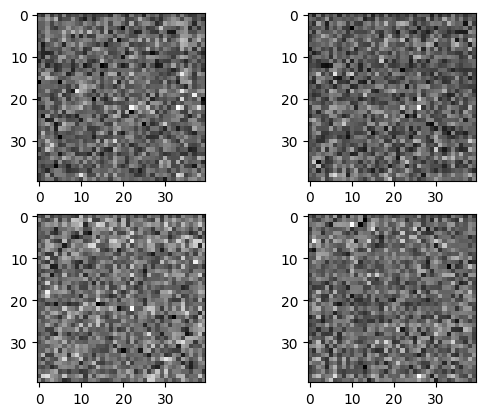

saved on epoch 0
saved on epoch 0
45/45 ━━━━━━━━━━━━━━━━━━━━ 45s 399ms/step - d_loss: 4.6584 - g_loss: -0.0172
Epoch 2/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -6.2425 - g_loss: 0.3815
Epoch 3/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -27.0921 - g_loss: 1.6795
Epoch 4/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -49.5546 - g_loss: 4.0165
Epoch 5/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -62.5121 - g_loss: 7.3818
Epoch 6/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


saved on epoch 5
saved on epoch 5
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -69.7945 - g_loss: 11.1726
Epoch 7/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -76.2379 - g_loss: 14.4241
Epoch 8/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -78.7769 - g_loss: 16.5903
Epoch 9/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -81.5545 - g_loss: 18.2085
Epoch 10/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -79.8362 - g_loss: 18.5084
Epoch 11/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


saved on epoch 10
saved on epoch 10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -81.2272 - g_loss: 18.4205
Epoch 12/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -81.6897 - g_loss: 18.4259
Epoch 13/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -79.4884 - g_loss: 17.9570
Epoch 14/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -78.6052 - g_loss: 16.0991
Epoch 15/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -76.8690 - g_loss: 14.1786
Epoch 16/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


saved on epoch 15


saved on epoch 15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -74.2135 - g_loss: 12.1148
Epoch 17/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -70.5654 - g_loss: 9.9375
Epoch 18/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -67.4322 - g_loss: 6.5516
Epoch 19/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -64.6731 - g_loss: 2.5500
Epoch 20/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -59.6975 - g_loss: -1.4717
Epoch 21/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


...

saved on epoch 280
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.3572 - g_loss: -1.7944
Epoch 282/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4491 - g_loss: -1.4916
Epoch 283/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4763 - g_loss: -1.7316
Epoch 284/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4111 - g_loss: -2.4714
Epoch 285/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3680 - g_loss: -2.1596
Epoch 286/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


saved on epoch 285


saved on epoch 285
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.4376 - g_loss: -2.6201
Epoch 287/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.5057 - g_loss: -2.1174
Epoch 288/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3546 - g_loss: -2.8846
Epoch 289/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2952 - g_loss: -2.5030
Epoch 290/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.5131 - g_loss: -3.3179
Epoch 291/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


saved on epoch 290
saved on epoch 290
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.2816 - g_loss: -3.1324
Epoch 292/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3484 - g_loss: -3.8926
Epoch 293/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.4176 - g_loss: -3.9610
Epoch 294/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2839 - g_loss: -3.6023
Epoch 295/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3520 - g_loss: -2.1717
Epoch 296/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


saved on epoch 295
saved on epoch 295
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.3376 - g_loss: -2.0338
Epoch 297/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3540 - g_loss: -2.1037
Epoch 298/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.3355 - g_loss: -1.8654
Epoch 299/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3049 - g_loss: -1.5522
Epoch 300/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2472 - g_loss: -1.5832
Epoch 301/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


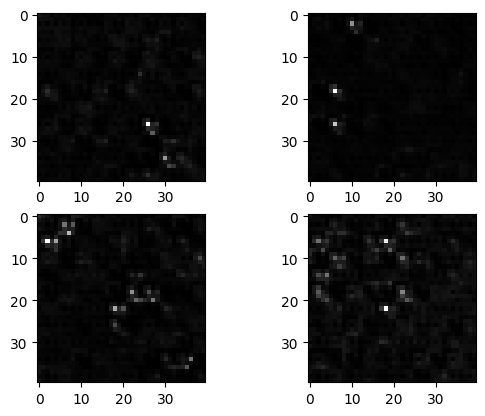

saved on epoch 300
saved on epoch 300
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - d_loss: -0.2888 - g_loss: -2.1304
Epoch 302/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2866 - g_loss: -2.0985
Epoch 303/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4459 - g_loss: -1.9133
Epoch 304/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3805 - g_loss: -2.0788
Epoch 305/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3624 - g_loss: -1.1779
Epoch 306/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


saved on epoch 305
saved on epoch 305
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.1710 - g_loss: -1.0587
Epoch 307/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.5381 - g_loss: -1.4156
Epoch 308/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4103 - g_loss: -1.0965
Epoch 309/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2886 - g_loss: -0.5035
Epoch 310/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2985 - g_loss: -0.2299
Epoch 311/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


saved on epoch 310
saved on epoch 310
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.4337 - g_loss: -0.6179
Epoch 312/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3211 - g_loss: -1.2258
Epoch 313/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4533 - g_loss: -1.7728
Epoch 314/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4720 - g_loss: -1.7654
Epoch 315/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3856 - g_loss: -1.5835
Epoch 316/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


saved on epoch 315


saved on epoch 315
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.3974 - g_loss: -1.8851
Epoch 317/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4206 - g_loss: -2.0025
Epoch 318/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4294 - g_loss: -1.4769
Epoch 319/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4331 - g_loss: -0.8791
Epoch 320/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3525 - g_loss: -0.7496
Epoch 321/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


...

saved on epoch 585
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.4056 - g_loss: 0.1145
Epoch 587/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3896 - g_loss: 0.6421
Epoch 588/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2073 - g_loss: 1.0488
Epoch 589/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3658 - g_loss: 0.2065
Epoch 590/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4608 - g_loss: 0.6537
Epoch 591/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


saved on epoch 590


saved on epoch 590
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.3462 - g_loss: 0.3263
Epoch 592/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3087 - g_loss: -0.5016
Epoch 593/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3572 - g_loss: -0.5629
Epoch 594/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2925 - g_loss: -0.7339
Epoch 595/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4632 - g_loss: -0.4490
Epoch 596/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


saved on epoch 595


saved on epoch 595
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.4354 - g_loss: 0.2534
Epoch 597/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.3442 - g_loss: -0.0210
Epoch 598/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3377 - g_loss: -0.2352
Epoch 599/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3612 - g_loss: -0.3210
Epoch 600/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4155 - g_loss: -0.7295
Epoch 601/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


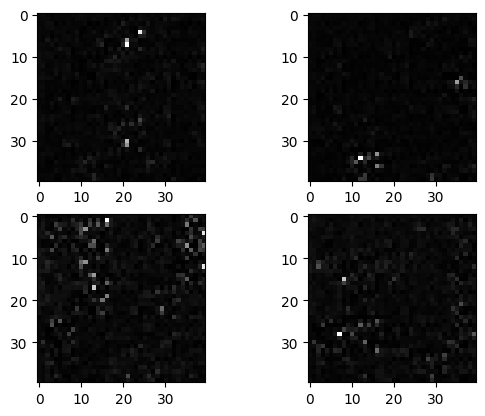

saved on epoch 600
saved on epoch 600
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - d_loss: -0.4017 - g_loss: -0.8242
Epoch 602/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4159 - g_loss: -0.6612
Epoch 603/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3424 - g_loss: -0.7583
Epoch 604/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3636 - g_loss: -0.7557
Epoch 605/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3610 - g_loss: -0.6780
Epoch 606/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


saved on epoch 605


saved on epoch 605
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.2587 - g_loss: -0.7403
Epoch 607/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3827 - g_loss: -0.6577
Epoch 608/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4122 - g_loss: -0.1617
Epoch 609/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4371 - g_loss: -0.4646
Epoch 610/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3530 - g_loss: -0.9679
Epoch 611/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


saved on epoch 610


saved on epoch 610
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.3496 - g_loss: -0.8779
Epoch 612/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3741 - g_loss: -0.9328
Epoch 613/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3603 - g_loss: -0.8952
Epoch 614/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2978 - g_loss: -1.2114
Epoch 615/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3138 - g_loss: -1.8298
Epoch 616/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


...

saved on epoch 885
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.4529 - g_loss: -3.1673
Epoch 887/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4692 - g_loss: -3.0151
Epoch 888/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3961 - g_loss: -2.9813
Epoch 889/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.4777 - g_loss: -2.9167
Epoch 890/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4015 - g_loss: -2.6965
Epoch 891/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


saved on epoch 890


saved on epoch 890
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.3730 - g_loss: -2.3529
Epoch 892/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4622 - g_loss: -2.5879
Epoch 893/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.4324 - g_loss: -2.8279
Epoch 894/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.3494 - g_loss: -3.1640
Epoch 895/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.3679 - g_loss: -2.9937
Epoch 896/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


saved on epoch 895


saved on epoch 895
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.1809 - g_loss: -2.4012
Epoch 897/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3675 - g_loss: -2.6041
Epoch 898/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3107 - g_loss: -2.4299
Epoch 899/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3311 - g_loss: -2.8064
Epoch 900/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3534 - g_loss: -2.9875
Epoch 901/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


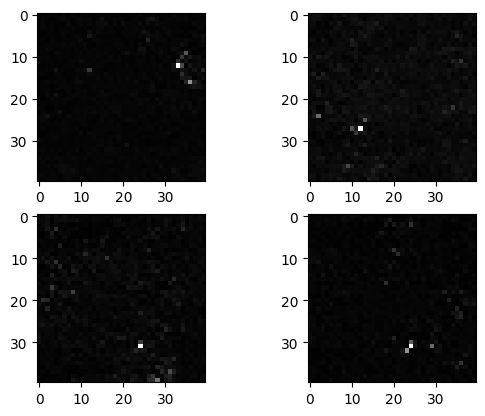

saved on epoch 900
saved on epoch 900
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - d_loss: -0.4061 - g_loss: -3.3222
Epoch 902/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3964 - g_loss: -3.0862
Epoch 903/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3933 - g_loss: -2.7330
Epoch 904/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.5438 - g_loss: -2.4905
Epoch 905/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4313 - g_loss: -2.4669
Epoch 906/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


saved on epoch 905
saved on epoch 905
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.5794 - g_loss: -3.3189
Epoch 907/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3138 - g_loss: -3.4798
Epoch 908/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4521 - g_loss: -3.2338
Epoch 909/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4612 - g_loss: -2.8365
Epoch 910/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3345 - g_loss: -3.0722
Epoch 911/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


saved on epoch 910
saved on epoch 910
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.3528 - g_loss: -3.1766
Epoch 912/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.3574 - g_loss: -3.1625
Epoch 913/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4635 - g_loss: -2.9627
Epoch 914/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4512 - g_loss: -2.8866
Epoch 915/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.3310 - g_loss: -2.8347
Epoch 916/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


saved on epoch 915


saved on epoch 915
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.2111 - g_loss: -2.7939
Epoch 917/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3715 - g_loss: -2.6311
Epoch 918/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3787 - g_loss: -2.5893
Epoch 919/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3946 - g_loss: -2.5643
Epoch 920/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4256 - g_loss: -2.4848
Epoch 921/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


...

saved on epoch 1185
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.4117 - g_loss: -2.7866
Epoch 1187/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.5525 - g_loss: -2.7414
Epoch 1188/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2804 - g_loss: -2.5980
Epoch 1189/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4870 - g_loss: -3.0110
Epoch 1190/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4988 - g_loss: -3.1739
Epoch 1191/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


saved on epoch 1190


saved on epoch 1190
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.4105 - g_loss: -3.0901
Epoch 1192/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.2185 - g_loss: -3.3719
Epoch 1193/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3563 - g_loss: -3.3959
Epoch 1194/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.2024 - g_loss: -3.2881
Epoch 1195/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3486 - g_loss: -3.2529
Epoch 1196/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


saved on epoch 1195


saved on epoch 1195
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.4187 - g_loss: -3.3780
Epoch 1197/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3855 - g_loss: -2.9013
Epoch 1198/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3548 - g_loss: -2.6494
Epoch 1199/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3704 - g_loss: -2.3786
Epoch 1200/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.1482 - g_loss: -2.2894
Epoch 1201/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


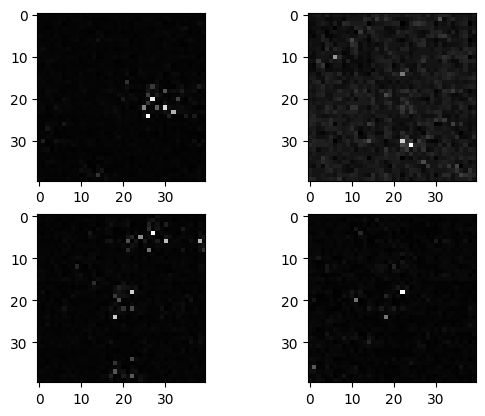

saved on epoch 1200
saved on epoch 1200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - d_loss: -0.5319 - g_loss: -2.3936
Epoch 1202/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3002 - g_loss: -3.2727
Epoch 1203/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3600 - g_loss: -3.3882
Epoch 1204/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4260 - g_loss: -3.4905
Epoch 1205/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4133 - g_loss: -3.5471
Epoch 1206/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


saved on epoch 1205


saved on epoch 1205
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.5217 - g_loss: -2.8164
Epoch 1207/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4441 - g_loss: -3.0100
Epoch 1208/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3146 - g_loss: -3.4986
Epoch 1209/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.5627 - g_loss: -3.3270
Epoch 1210/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3869 - g_loss: -3.1678
Epoch 1211/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


saved on epoch 1210


saved on epoch 1210
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.6342 - g_loss: -3.2277
Epoch 1212/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2583 - g_loss: -3.2229
Epoch 1213/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4263 - g_loss: -2.9314
Epoch 1214/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3936 - g_loss: -2.4557
Epoch 1215/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3483 - g_loss: -3.0022
Epoch 1216/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


...

saved on epoch 1485
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.4639 - g_loss: -2.9566
Epoch 1487/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3839 - g_loss: -3.0644
Epoch 1488/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.3668 - g_loss: -3.3683
Epoch 1489/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3488 - g_loss: -3.0750
Epoch 1490/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.3712 - g_loss: -3.0975
Epoch 1491/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


saved on epoch 1490


saved on epoch 1490
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.4514 - g_loss: -3.0380
Epoch 1492/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2698 - g_loss: -2.9890
Epoch 1493/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.4019 - g_loss: -2.6105
Epoch 1494/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.5753 - g_loss: -2.6727
Epoch 1495/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4428 - g_loss: -2.6016
Epoch 1496/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


saved on epoch 1495


saved on epoch 1495
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.3541 - g_loss: -2.4268
Epoch 1497/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4117 - g_loss: -2.9409
Epoch 1498/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.3578 - g_loss: -2.5152
Epoch 1499/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.1708 - g_loss: -3.0840
Epoch 1500/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3219 - g_loss: -2.7920
Epoch 1501/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


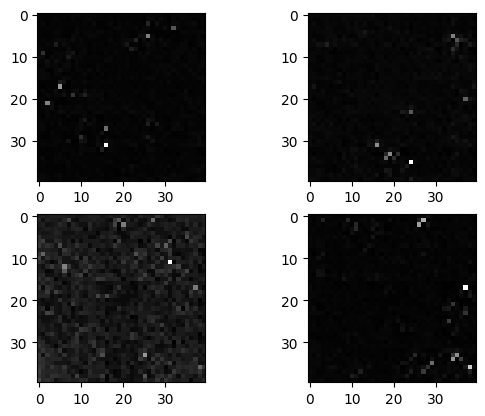

saved on epoch 1500
saved on epoch 1500
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - d_loss: -0.4011 - g_loss: -2.2521
Epoch 1502/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.4767 - g_loss: -2.0736
Epoch 1503/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3264 - g_loss: -2.1535
Epoch 1504/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3426 - g_loss: -3.1853
Epoch 1505/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2733 - g_loss: -3.3961
Epoch 1506/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


saved on epoch 1505


saved on epoch 1505
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.3992 - g_loss: -3.3644
Epoch 1507/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3648 - g_loss: -2.9214
Epoch 1508/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3173 - g_loss: -2.5117
Epoch 1509/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.5175 - g_loss: -1.8649
Epoch 1510/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3164 - g_loss: -2.0758
Epoch 1511/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


saved on epoch 1510


saved on epoch 1510
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.4442 - g_loss: -2.4675
Epoch 1512/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4317 - g_loss: -2.3508
Epoch 1513/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2913 - g_loss: -2.1922
Epoch 1514/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3028 - g_loss: -2.0516
Epoch 1515/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2260 - g_loss: -1.8554
Epoch 1516/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


...

saved on epoch 1785


saved on epoch 1785
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.2595 - g_loss: -0.3095
Epoch 1787/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3043 - g_loss: -0.5659
Epoch 1788/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3849 - g_loss: -0.1856
Epoch 1789/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3052 - g_loss: -0.2716
Epoch 1790/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.4084 - g_loss: -0.1738
Epoch 1791/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


saved on epoch 1790
saved on epoch 1790
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.2271 - g_loss: -0.5528
Epoch 1792/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4048 - g_loss: -0.2650
Epoch 1793/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3543 - g_loss: -0.2398
Epoch 1794/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3126 - g_loss: -0.5825
Epoch 1795/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3249 - g_loss: -0.2655
Epoch 1796/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


saved on epoch 1795


saved on epoch 1795
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.3550 - g_loss: 0.0295
Epoch 1797/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2923 - g_loss: -0.5799
Epoch 1798/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.3384 - g_loss: -1.1037
Epoch 1799/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4123 - g_loss: -1.2825
Epoch 1800/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2942 - g_loss: -1.5862
Epoch 1801/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


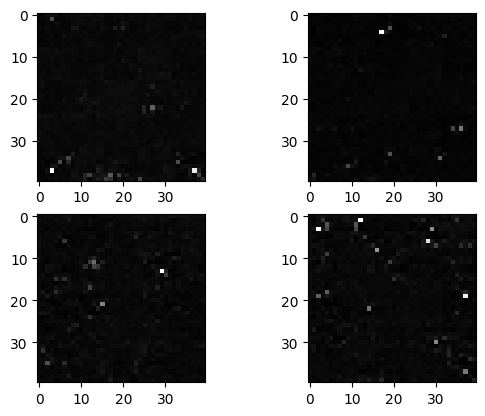

saved on epoch 1800
saved on epoch 1800
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - d_loss: -0.3496 - g_loss: -1.7644
Epoch 1802/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.1913 - g_loss: -1.9287
Epoch 1803/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.4102 - g_loss: -1.9674
Epoch 1804/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2945 - g_loss: -2.0291
Epoch 1805/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4076 - g_loss: -1.9026
Epoch 1806/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


saved on epoch 1805


saved on epoch 1805
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.3984 - g_loss: -1.6654
Epoch 1807/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4457 - g_loss: -1.0866
Epoch 1808/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3766 - g_loss: -0.6910
Epoch 1809/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.1702 - g_loss: -0.4871
Epoch 1810/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3206 - g_loss: -0.4581
Epoch 1811/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


saved on epoch 1810


saved on epoch 1810
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.4171 - g_loss: -1.4895
Epoch 1812/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3671 - g_loss: -1.7692
Epoch 1813/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2787 - g_loss: -1.2724
Epoch 1814/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4828 - g_loss: -1.3649
Epoch 1815/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2489 - g_loss: -1.6377
Epoch 1816/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


...

saved on epoch 2085
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.3193 - g_loss: -0.5644
Epoch 2087/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2784 - g_loss: -0.6841
Epoch 2088/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2924 - g_loss: -1.1026
Epoch 2089/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4787 - g_loss: -1.1431
Epoch 2090/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.2654 - g_loss: -1.3591
Epoch 2091/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


saved on epoch 2090


saved on epoch 2090
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.2652 - g_loss: -1.5994
Epoch 2092/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.2929 - g_loss: -1.1421
Epoch 2093/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.3406 - g_loss: -1.3059
Epoch 2094/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3994 - g_loss: -1.3632
Epoch 2095/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.2913 - g_loss: -1.3419
Epoch 2096/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


saved on epoch 2095


saved on epoch 2095
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.3689 - g_loss: -1.5316
Epoch 2097/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.3091 - g_loss: -1.6359
Epoch 2098/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2165 - g_loss: -1.7347
Epoch 2099/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3334 - g_loss: -2.0332
Epoch 2100/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2764 - g_loss: -2.0451
Epoch 2101/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


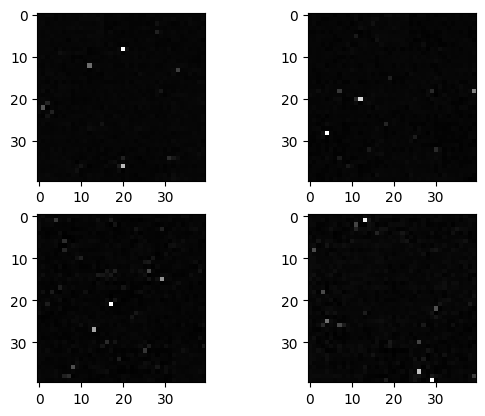

saved on epoch 2100
saved on epoch 2100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - d_loss: -0.2305 - g_loss: -1.6730
Epoch 2102/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.3115 - g_loss: -1.2559
Epoch 2103/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2973 - g_loss: -1.3781
Epoch 2104/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.1987 - g_loss: -1.6046
Epoch 2105/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3137 - g_loss: -1.5510
Epoch 2106/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


saved on epoch 2105
saved on epoch 2105
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.3352 - g_loss: -1.8428
Epoch 2107/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2110 - g_loss: -2.2017
Epoch 2108/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3043 - g_loss: -2.1748
Epoch 2109/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.1811 - g_loss: -2.0262
Epoch 2110/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2874 - g_loss: -1.8194
Epoch 2111/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


saved on epoch 2110


saved on epoch 2110
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.3800 - g_loss: -2.0637
Epoch 2112/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2324 - g_loss: -2.3979
Epoch 2113/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.3097 - g_loss: -2.3994
Epoch 2114/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.2549 - g_loss: -1.6785
Epoch 2115/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2503 - g_loss: -1.4220
Epoch 2116/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


saved on epoch 2115


...

saved on epoch 2385
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.1966 - g_loss: 0.4537
Epoch 2387/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.4457 - g_loss: 0.1630
Epoch 2388/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.1751 - g_loss: -0.0337
Epoch 2389/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.2636 - g_loss: 0.0139
Epoch 2390/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.2502 - g_loss: 0.0700
Epoch 2391/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


saved on epoch 2390


saved on epoch 2390
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - d_loss: -0.1845 - g_loss: 0.1280
Epoch 2392/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3591 - g_loss: 0.2301
Epoch 2393/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2519 - g_loss: 0.4359
Epoch 2394/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.2440 - g_loss: 0.2884
Epoch 2395/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.1394 - g_loss: 0.3983
Epoch 2396/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


saved on epoch 2395


saved on epoch 2395
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.3305 - g_loss: 0.6859
Epoch 2397/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.1772 - g_loss: 0.7815
Epoch 2398/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2216 - g_loss: 0.5709
Epoch 2399/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2492 - g_loss: 0.4999
Epoch 2400/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.3468 - g_loss: 0.1848
Epoch 2401/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


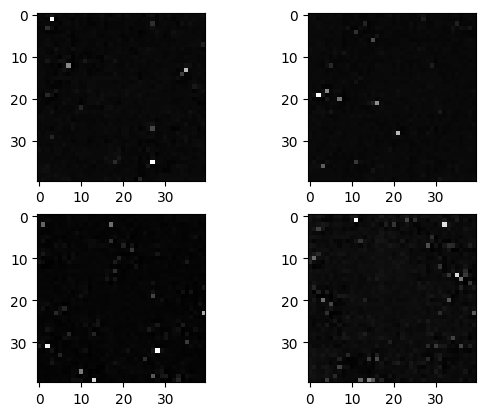

saved on epoch 2400
saved on epoch 2400
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - d_loss: -0.2204 - g_loss: 0.3287
Epoch 2402/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.3237 - g_loss: 0.8247
Epoch 2403/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.1410 - g_loss: 1.0455
Epoch 2404/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.2369 - g_loss: 1.2894
Epoch 2405/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.2236 - g_loss: 1.1326
Epoch 2406/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


saved on epoch 2405


saved on epoch 2405
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - d_loss: -0.3669 - g_loss: 1.4396
Epoch 2407/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.2711 - g_loss: 1.7812
Epoch 2408/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2908 - g_loss: 0.9891
Epoch 2409/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2695 - g_loss: 0.7337
Epoch 2410/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2863 - g_loss: 0.5256
Epoch 2411/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


saved on epoch 2410


saved on epoch 2410
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.2772 - g_loss: 0.3591
Epoch 2412/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2834 - g_loss: 0.0062
Epoch 2413/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3428 - g_loss: 0.4174
Epoch 2414/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.1893 - g_loss: 0.6139
Epoch 2415/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2492 - g_loss: 0.9229
Epoch 2416/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


...

saved on epoch 2685
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.3189 - g_loss: 1.6371
Epoch 2687/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2599 - g_loss: 1.2995
Epoch 2688/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.1974 - g_loss: 1.4036
Epoch 2689/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.0591 - g_loss: 1.9599
Epoch 2690/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2205 - g_loss: 1.8782
Epoch 2691/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


saved on epoch 2690


saved on epoch 2690
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.3277 - g_loss: 1.7338
Epoch 2692/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.0459 - g_loss: 1.7137
Epoch 2693/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.1738 - g_loss: 1.6823
Epoch 2694/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.4207 - g_loss: 2.0890
Epoch 2695/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.1816 - g_loss: 1.9446
Epoch 2696/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


saved on epoch 2695


saved on epoch 2695
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.1619 - g_loss: 1.9233
Epoch 2697/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.1465 - g_loss: 1.8922
Epoch 2698/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.3559 - g_loss: 1.8601
Epoch 2699/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.2962 - g_loss: 1.8071
Epoch 2700/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2834 - g_loss: 1.7677
Epoch 2701/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


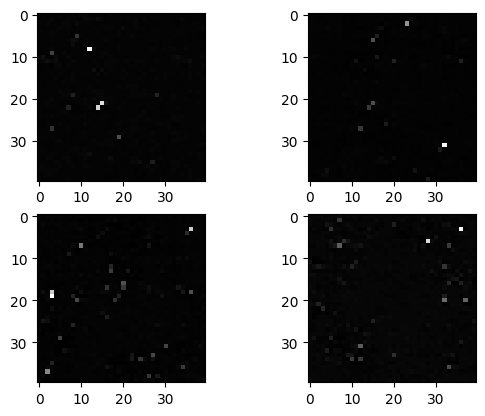

saved on epoch 2700
saved on epoch 2700
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - d_loss: -0.3300 - g_loss: 1.8555
Epoch 2702/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3113 - g_loss: 2.4819
Epoch 2703/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2402 - g_loss: 1.9942
Epoch 2704/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2745 - g_loss: 1.9307
Epoch 2705/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.1229 - g_loss: 2.0784
Epoch 2706/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


saved on epoch 2705
saved on epoch 2705
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.1646 - g_loss: 1.9472
Epoch 2707/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3296 - g_loss: 1.7086
Epoch 2708/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3769 - g_loss: 1.9037
Epoch 2709/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3115 - g_loss: 1.7264
Epoch 2710/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.1239 - g_loss: 1.4135
Epoch 2711/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


saved on epoch 2710


saved on epoch 2710
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.0310 - g_loss: 1.8585
Epoch 2712/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.2298 - g_loss: 1.9132
Epoch 2713/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2847 - g_loss: 1.8976
Epoch 2714/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.1880 - g_loss: 1.9271
Epoch 2715/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.0652 - g_loss: 1.7820
Epoch 2716/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


saved on epoch 2715


...

saved on epoch 2985
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.2162 - g_loss: -0.3586
Epoch 2987/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.2490 - g_loss: -0.5027
Epoch 2988/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.1326 - g_loss: -0.2244
Epoch 2989/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.2642 - g_loss: -0.8362
Epoch 2990/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: 0.0124 - g_loss: -0.9787
Epoch 2991/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


saved on epoch 2990


saved on epoch 2990
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.3112 - g_loss: -0.7427
Epoch 2992/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.1629 - g_loss: -0.2305
Epoch 2993/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.2364 - g_loss: -0.0122
Epoch 2994/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.1872 - g_loss: -0.0942
Epoch 2995/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.5607 - g_loss: 0.1027
Epoch 2996/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


saved on epoch 2995


saved on epoch 2995
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - d_loss: -0.0862 - g_loss: 0.2001
Epoch 2997/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.0991 - g_loss: 0.1127
Epoch 2998/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.0760 - g_loss: 0.8764
Epoch 2999/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - d_loss: -0.1220 - g_loss: 1.0877
Epoch 3000/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - d_loss: -0.3324 - g_loss: 0.3863


In [ ]:
cond_gan = ConditionalGAN(
    discriminator=get_discriminator(),
    generator=get_geneator(),
    latent_dim=latent_dim ,
    batch_size=batch_size
)
cond_gan.compile(
    d_optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5, beta_1=0.5, beta_2=0.9),
    g_optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5, beta_1=0.5, beta_2=0.9),
    g_loss_fn=generator_loss,
    d_loss_fn=discriminator_loss,
)

hist=cond_gan.fit(dataset, epochs=3000 ,callbacks=[callback])

Training from where we stopped

Loading models from epoch 0


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
mean -0.006863095331937075 std 0.010661272332072258
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.89394873]
 [0.8943579 ]
 [0.8914422 ]
 [0.89835167]]


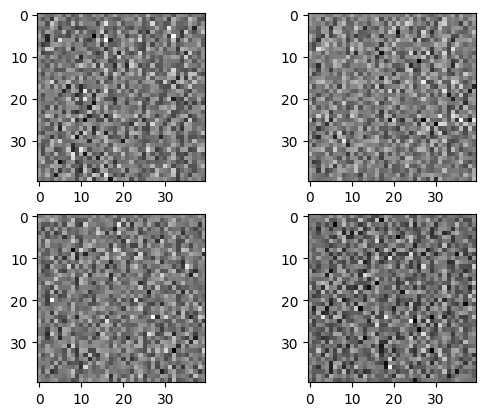

saved on epoch 0
saved on epoch 0
45/45 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - d_loss: 4.1658 - g_loss: 0.4648
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.012542043812572956 std 0.011289775371551514
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.8914923 ]
 [0.88899344]
 [0.8927913 ]
 [0.8918607 ]]
45/45 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - d_loss: 0.8475 - g_loss: 1.1527
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
mean -0.019074128940701485 std 0.013108020648360252
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
prediction [[0.88931847]
 [0.8869772 ]
 [0.8917377 ]
 [0.8892639 ]]
45/45 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - d_loss: -3.1815 - g_loss: 2.7513
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
mean -0.026039279997348785 std 0.014708086848258972
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.88936895]
 [0.8863572 ]
 [0.8859214 ]
 [0.88670665]]
45/45 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - d_loss: -6.7601 - g_loss: 4.8262
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/ste

prediction [[0.8775651]
 [0.8755952]
 [0.8819174]
 [0.87728  ]]
saved on epoch 5


saved on epoch 5
45/45 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - d_loss: -10.6104 - g_loss: 4.7734
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
mean -0.052770089358091354 std 0.020521244034171104
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.869335  ]
 [0.87389886]
 [0.87094736]
 [0.8722148 ]]
45/45 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - d_loss: -11.1947 - g_loss: 3.2193
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.06371157616376877 std 0.0225429218262434
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.8640977 ]
 [0.86148727]
 [0.86548775]
 [0.8676572 ]]
45/45 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - d_loss: -11.3588 - g_loss: 1.7067
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.07818109542131424 std 0.025896843522787094
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
prediction [[0.85347396]
 [0.85323393]
 [0.85807   ]
 [0.85581106]]
45/45 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - d_loss: -10.8458 - g_loss: 0.6577
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
mean -0.0952

prediction [[0.8278692 ]
 [0.8302259 ]
 [0.8290427 ]
 [0.82756776]]
saved on epoch 10
saved on epoch 10
45/45 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - d_loss: -9.6570 - g_loss: -1.1946
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.13057000935077667 std 0.03617630898952484
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction [[0.80887216]
 [0.8114604 ]
 [0.8137605 ]
 [0.81207305]]
45/45 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - d_loss: -8.6745 - g_loss: -2.2701
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
mean -0.15641145408153534 std 0.04256124421954155
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction [[0.79427844]
 [0.7942725 ]
 [0.7934715 ]
 [0.78989804]]
45/45 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - d_loss: -7.3962 - g_loss: -3.3772
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
mean -0.18174037337303162 std 0.04875486344099045
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
prediction [[0.76229584]
 [0.7877551 ]
 [0.76712054]
 [0.7809577 ]]
45/45 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - d_loss: -

KeyboardInterrupt: 

In [ ]:
import glob
import re

def load_latest_model():
    # Use the path to your Google Drive folder
    generator_files = glob.glob("'/content/drive/MyDrive/Ahsan/11. Cancer Data on 30th April//Generator Model/generator_Epoch-*.h5")
    discriminator_files = glob.glob("'/content/drive/MyDrive/Ahsan/11. Cancer Data on 30th April//Discriminator Model/discriminator_Epoch-*.h5")

    if not generator_files or not discriminator_files:
        print("No files here ")
        return None, None

    # searches files to get epoch numbers
    epochs = [int(re.search(r"Epoch-(\d+)", f).group(1)) for f in generator_files]
    # this return largest epoch
    latest_epoch = max(epochs)

    # loading that generator and dsicriminator file with
    generator_filename = f'/content/drive/MyDrive/Ahsan/11. Cancer Data on 30th April/Generator Model/generator_Epoch-{latest_epoch}.h5'
    discriminator_filename = f'/content/drive/MyDrive/Ahsan/11. Cancer Data on 30th April/Discriminator Model/discriminator_Epoch-{latest_epoch}.h5'

    print(f"Loading models from epoch {latest_epoch}")
    generator = tf.keras.models.load_model(generator_filename)
    discriminator = tf.keras.models.load_model(discriminator_filename)
    return generator, discriminator, latest_epoch

generator, discriminator, latest_epoch= load_latest_model()


cond_gan = ConditionalGAN(
    discriminator=discriminator,
    generator=generator,
    latent_dim=latent_dim,
    batch_size=batch_size
)

# Compile the ConditionalGAN with the same loss and optimizer functions
cond_gan.compile(
    d_optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5, beta_1=0.5, beta_2=0.9),
    g_optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5, beta_1=0.5, beta_2=0.9),
    g_loss_fn=generator_loss,
    d_loss_fn=discriminator_loss,
)

# Continue training for an additional epochs
hist = cond_gan.fit(dataset, initial_epoch=latest_epoch, epochs=100, callbacks=[callback])

In [ ]:
cond_gan.generator.save('/content/drive/MyDrive/Ahsan/11. Cancer Data on 30th April/generator.h5')

Synthetic File Generation

In [ ]:
# Synthetic Image Generation as .npy file
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
import os

# Paths
generator_path = '/content/drive/MyDrive/Ahsan/11. Cancer Data on 30th April/Generator Model/generator_Epoch-2725.h5'
save_file = '/content/drive/MyDrive/Ahsan/11. Cancer Data on 30th April/synthetic_High_2725.npy'

# Load the generator model
generator = load_model(generator_path)
print("Generator model loaded successfully.")

# Function to generate and save synthetic images as a single .npy file
def generate_and_save_images(generator, latent_dim, desired_label, save_file, num_samples=1415):
    # Generate noise and labels
    noise = tf.random.normal(shape=(num_samples, latent_dim))
    labels = np.full((num_samples, 1), desired_label)  # Fill with the desired label

    # Generate synthetic images
    synthetic_images = generator.predict([noise, labels])

    # Verify the shape of synthetic images
    print("Generated images shape:", synthetic_images.shape)

    # Save the entire array as a single .npy file
    np.save(save_file, synthetic_images)
    print(f"Synthetic images saved to: {save_file}")

# Example Usage
latent_dim = 128  # Should match the latent_dim used during training
num_samples = 1415  # Number of samples to generate

# Specify the label for the desired class
# Use -0.5 for low class or 0.5 for high class
desired_label = 0.5  # Change to 0.5 for high class

generate_and_save_images(generator, latent_dim, desired_label, save_file, num_samples)

Generator model loaded successfully.
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Generated images shape: (1415, 40, 40, 1)
Synthetic images saved to: /content/drive/MyDrive/Ahsan/11. Cancer Data on 30th April/synthetic_High_2725.npy


Multiple Synthetic Files Generation


In [ ]:
# Synthetic Image Generation from multiple generator models
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
import os

# Paths
generator_dir = '/content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/Generator Model/'
save_dir = '/content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/5. Synthetic files from Generator'

# Function to generate and save synthetic images
def generate_and_save_images(generator, latent_dim, desired_label, save_file, num_samples=1415):
    # Generate noise and labels
    noise = tf.random.normal(shape=(num_samples, latent_dim))
    labels = np.full((num_samples, 1), desired_label)

    # Generate synthetic images
    synthetic_images = generator.predict([noise, labels])

    # Save the entire array as a single .npy file
    np.save(save_file, synthetic_images)
    print(f"Synthetic images saved to: {save_file}")

# User input for model range
start_epoch = int(input("Enter the starting epoch number: "))
end_epoch = int(input("Enter the ending epoch number: "))

# Parameters
latent_dim = 128
num_samples = 1415

# Loop through the specified range of generator models
for epoch in range(start_epoch, end_epoch + 1, 5):  # Assuming .h5 files are saved every 5 epochs
    generator_path = os.path.join(generator_dir, f'generator_Epoch-{epoch}.h5')

    if os.path.exists(generator_path):
        print(f"Loading generator model from: {generator_path}")
        generator = load_model(generator_path)

        # Generate and save High class images
        save_file_high = os.path.join(save_dir, f'synthetic_High_Epoch-{epoch}.npy')
        generate_and_save_images(generator, latent_dim, 0.5, save_file_high, num_samples)

        # Generate and save Low class images
        save_file_low = os.path.join(save_dir, f'synthetic_Low_Epoch-{epoch}.npy')
        generate_and_save_images(generator, latent_dim, -0.5, save_file_low, num_samples)

    else:
        print(f"Model file not found: {generator_path}, skipping...")


Enter the starting epoch number: 900
Enter the ending epoch number: 935
Loading generator model from: /content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/Generator Model/generator_Epoch-900.h5


45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Synthetic images saved to: /content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/5. Synthetic files from Generator/synthetic_High_Epoch-900.npy
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Synthetic images saved to: /content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/5. Synthetic files from Generator/synthetic_Low_Epoch-900.npy
Loading generator model from: /content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/Generator Model/generator_Epoch-905.h5


45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Synthetic images saved to: /content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/5. Synthetic files from Generator/synthetic_High_Epoch-905.npy
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Synthetic images saved to: /content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/5. Synthetic files from Generator/synthetic_Low_Epoch-905.npy
Loading generator model from: /content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/Generator Model/generator_Epoch-910.h5


45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Synthetic images saved to: /content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/5. Synthetic files from Generator/synthetic_High_Epoch-910.npy
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Synthetic images saved to: /content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/5. Synthetic files from Generator/synthetic_Low_Epoch-910.npy
Loading generator model from: /content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/Generator Model/generator_Epoch-915.h5


45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Synthetic images saved to: /content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/5. Synthetic files from Generator/synthetic_High_Epoch-915.npy
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Synthetic images saved to: /content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/5. Synthetic files from Generator/synthetic_Low_Epoch-915.npy
Loading generator model from: /content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/Generator Model/generator_Epoch-920.h5


45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Synthetic images saved to: /content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/5. Synthetic files from Generator/synthetic_High_Epoch-920.npy
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Synthetic images saved to: /content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/5. Synthetic files from Generator/synthetic_Low_Epoch-920.npy
Loading generator model from: /content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/Generator Model/generator_Epoch-925.h5


45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Synthetic images saved to: /content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/5. Synthetic files from Generator/synthetic_High_Epoch-925.npy
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Synthetic images saved to: /content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/5. Synthetic files from Generator/synthetic_Low_Epoch-925.npy
Loading generator model from: /content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/Generator Model/generator_Epoch-930.h5


45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
Synthetic images saved to: /content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/5. Synthetic files from Generator/synthetic_High_Epoch-930.npy
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Synthetic images saved to: /content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/5. Synthetic files from Generator/synthetic_Low_Epoch-930.npy
Loading generator model from: /content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/Generator Model/generator_Epoch-935.h5


45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Synthetic images saved to: /content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/5. Synthetic files from Generator/synthetic_High_Epoch-935.npy
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Synthetic images saved to: /content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/5. Synthetic files from Generator/synthetic_Low_Epoch-935.npy


Loss Function Plot

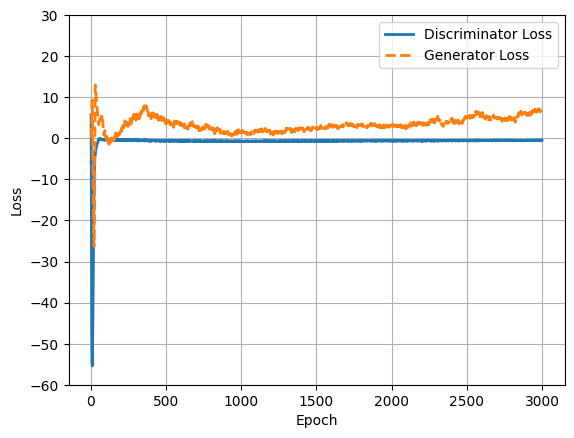

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the extracted loss data
csv_path = "/content/drive/MyDrive/Ahsan/10. Cancer Data High Low Rework/extracted_losses_6thMarch.csv"  # Ensure the correct file path
df = pd.read_csv(csv_path)

# Plot Discriminator and Generator Loss
plt.plot(df['Epoch'], df['D_Loss'], linewidth=2, label='Discriminator Loss')
plt.plot(df['Epoch'], df['G_Loss'], linewidth=2, linestyle='dashed', label='Generator Loss')

# Labels and formatting
plt.ylabel('Loss')
plt.ylim(-60, 30)
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

# Show plot
plt.show()
